##### Name : Febriani Patricia
##### Student Number: 48914127

**QUESTION 1 Data Preparation**

In [463]:
import pandas as pd

# load the data
chemical_analysis = pd.read_csv(filepath_or_buffer='wine.csv')

chemical_analysis.head(40)

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1.0,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1.0,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1.0,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1.0,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,1.0,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,1.0,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,1.0,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,1.0,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,1.0,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


In [464]:
#Idenifiying missing data
chemical_analysis.isna().sum()

Wine                    1
Alcohol                 3
Malic.acid              1
Ash                     0
Acl                     7
Mg                      1
Phenols                 4
Flavanoids              4
Nonflavanoid.phenols    1
Proanth                 0
Color.int               6
Hue                     0
OD                      1
Proline                 7
dtype: int64

In [465]:
#Data information
chemical_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  177 non-null    float64
 1   Alcohol               175 non-null    float64
 2   Malic.acid            177 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   171 non-null    float64
 5   Mg                    177 non-null    float64
 6   Phenols               174 non-null    float64
 7   Flavanoids            174 non-null    float64
 8   Nonflavanoid.phenols  177 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             172 non-null    float64
 11  Hue                   178 non-null    object 
 12  OD                    177 non-null    float64
 13  Proline               171 non-null    float64
dtypes: float64(13), object(1)
memory usage: 19.6+ KB


In [466]:
# Select columns with string values
string_cols = chemical_analysis.select_dtypes(include=[object]).columns

# Convert comma to dot and convert to float
chemical_analysis_conv = chemical_analysis.copy()
for col in string_cols:
    chemical_analysis_conv[col] = chemical_analysis_conv[col].str.replace(',', '.').astype(float)

# Impute missing value by mode
new_value = chemical_analysis_conv.fillna(chemical_analysis_conv.mode().iloc[0])

# Fill missing values with the mode
fill = new_value

fill.head(40)

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1.0,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1.0,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1.0,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1.0,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,1.0,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,1.0,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,1.0,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,1.0,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,1.0,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


In [467]:
#Check if imputation success
fill.isna().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

To handle the missing data, we can do:

1. Remove rows of missing data (not recommended; leads to loss of data)
   Discarding rows with missing data is often not recommended, as it may lead to the loss of potentially valuable insights. When the level of missing data is high, this approach can substantially reduce the sample size, which may result in analyses that are biased or less reliable.
   
2. Find the replacement values for the missing values from the original source of data (recommended)
   This solution is highly effective as it reverts the dataset to its initial configuration with accurate data. However, it may not always be achievable, especially in cases where the original source is unavailable.

   
**3. Impute the missing data using the best estimate of the missing values based on non-missing values (recommended)**

Imputation refers to the process of substituting missing data with estimated values. This technique enables the inclusion of all observations within the dataset, which is essential for preserving the integrity of the analysis.

It appears that the wine values are predominantly restricted to the numbers 1, 2, and 3. Furthermore, I noticed a missing data value in the wine column, which led me to apply mode imputation to resolve the missing data issue in the wine.csv file. This method is effective because it replaces the missing values with the most common value, ensuring that the imputed data aligns with the prevalent pattern within the dataset. Furthermore, it helps to avoid the potential distortion of the distribution that could occur with mean, median, or random imputation.

-- This code handles missing data by first identifying columns with string values and converting numeric strings, which use commas as decimal separators, to dots, then converting them to floats for numerical analysis. This conversion is necessary because numeric operations in Python require numbers to be in a standard float format with dots as decimal separators. After conversion, missing values are imputed using the mode of each column, rounded to two decimal places, and filled in. Finally, the first 40 rows of the processed DataFrame are displayed for review.
   

**QUESTION 2 Exploratory Data Analysis (EDA)**

#### 2. 1 Univariate EDA

##### 2.1.1 Column 'Wine'

In [404]:
print('number of duplication: ' ,fill.duplicated().sum(), "\n")

# summarize
print('Summarize: ')
print(fill["Wine"].describe(), "\n")
print('Unique value: ' ,fill["Wine"].unique())

number of duplication:  0 

Summarize: 
count    178.000000
mean       1.932584
std        0.770908
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: Wine, dtype: float64 

Unique value:  [1. 2. 3.]


In [405]:
# distribution of the 'Wine' column
wine_distribution = fill["Wine"].value_counts().nlargest(10)
wine_distribution

Wine
2.0    72
1.0    59
3.0    47
Name: count, dtype: int64

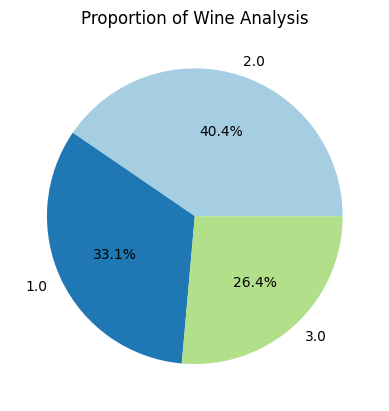

In [406]:
# plot distribution of the 'Wine' column
wine_distribution.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Proportion of Wine Analysis')
plt.ylabel('')
plt.show()

**Analysis:**

From the plot above, using mode or value counting, it is evident that wine 2 (cultivator 2) is the most common, indicating that it was more extensively analised. However, this imbalance in sample size could lead to potential bias in the analysis, as the significantly larger number of samples from cultivator 2 may skew the results. The comparative analysis between the cultivators may be affected due to this gap in sample representation, making it crucial to consider this imbalance when interpreting the findings.

##### 2.1.2 Column 'Alcohol'

In [407]:
# summarize
print('Summarize: ')
print(fill["Alcohol"].describe(), "\n")
print('Unique value: ' ,fill["Alcohol"].unique())

Summarize: 
count    178.000000
mean      12.994213
std        0.810301
min       11.030000
25%       12.370000
50%       13.050000
75%       13.677500
max       14.830000
Name: Alcohol, dtype: float64 

Unique value:  [14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 12.93 13.71 12.85 13.5
 13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48 13.28
 13.07 14.22 13.56 13.41 13.88 14.21 13.9  13.94 13.82 13.77 13.74 12.37
 13.29 13.72 12.33 12.64 13.67 12.17 13.11 13.34 12.21 12.29 13.49 12.99
 11.96 11.66 13.03 11.84 12.7  12.   12.72 12.08 12.67 12.16 11.65 11.64
 12.69 11.62 12.47 11.81 12.6  12.34 11.82 12.51 12.42 12.25 12.22 11.61
 11.46 12.52 11.76 11.41 11.03 12.77 11.45 11.56 12.07 12.43 11.79 12.04
 12.86 12.88 12.81 12.53 12.84 13.36 13.52 13.62 12.87 13.32 13.08 12.79
 13.23 12.58 13.17 13.84 12.45 14.34 12.36 13.69 12.96 13.78 13.45 13.4
 12.2  14.16 13.27 14.13]


In [408]:
# distribution of the 'Alcohol' column
alcohol_distribution = fill["Alcohol"].value_counts().nlargest(10).sort_index()
alcohol_distribution

Alcohol
11.84    2
12.00    3
12.08    5
12.25    3
12.29    4
12.37    9
12.42    3
13.05    6
13.58    2
14.22    2
Name: count, dtype: int64

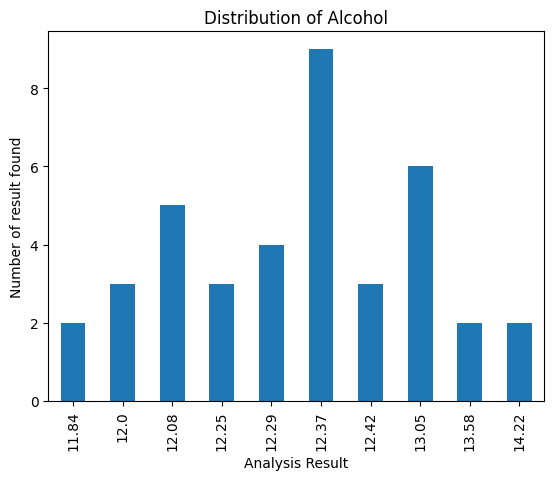

In [409]:
# plot distribution of the 'Alcohol' column
alcohol_distribution.plot.bar(xlabel="Analysis Result", ylabel="Number of result found", grid=False, title="Distribution of Alcohol");

**Analysis:**

This plot shows the distribution of alcohol content in the range of 11.84 to 14.22. The most frequent alcohol content found in the wine samples is 12.37, with 9 occurrences and the average alcohol content, based on the plot data, is approximately 12.52

##### 2.1.3 Column 'Color.int'

In [410]:
# summarize
print('Summarize: ')
print(fill["Color.int"].describe(), "\n")
print('Unique value: ' ,fill["Color.int"].unique())

Summarize: 
count    178.000000
mean       4.958371
std        2.316597
min        1.280000
25%        3.050000
50%        4.600000
75%        6.122500
max       13.000000
Name: Color.int, dtype: float64 

Unique value:  [ 5.64  4.38  5.68  7.8   4.32  6.75  5.25  5.05  5.2   7.22  5.75  5.
  5.6   5.4   7.5   2.6   6.2   6.6   8.7   5.65  4.5   3.8   3.93  3.52
  3.58  4.8   4.7   5.7   6.9   3.84  4.2   5.1   4.6   4.25  3.7   6.13
  4.28  5.43  4.36  5.04  5.24  4.9   6.1   8.9   7.2   7.05  6.3   5.85
  6.25  6.38  6.    6.8   1.95  3.27  2.95  5.3   4.68  3.17  2.85  3.05
  3.38  3.74  3.35  3.21  3.4   2.57  2.5   3.9   2.2   2.62  2.45  2.8
  1.74  2.4   3.6   2.15  3.25  2.9   2.3   3.3   2.06  2.94  2.7   2.65
  2.    3.08  1.9   1.28  2.08  2.76  3.94  3.    2.12  4.1   5.45  7.1
  3.85  4.92  4.35  4.4   8.21  4.    7.65  8.42  9.4   8.6  10.8  10.52
  7.6   7.9   9.01 13.   11.75  5.88  5.58  5.28  9.58  6.62 10.68 10.26
  8.66  8.5   5.5   9.7   7.7   7.3  10.2   9.3   9.2

In [411]:
# distribution of the 'Color.int' column
color_distribution = fill["Color.int"].value_counts().nlargest(10).sort_index()
color_distribution

Color.int
2.60    10
2.80     3
3.05     3
3.40     3
3.80     4
4.50     3
4.60     4
5.00     3
5.40     3
5.60     3
Name: count, dtype: int64

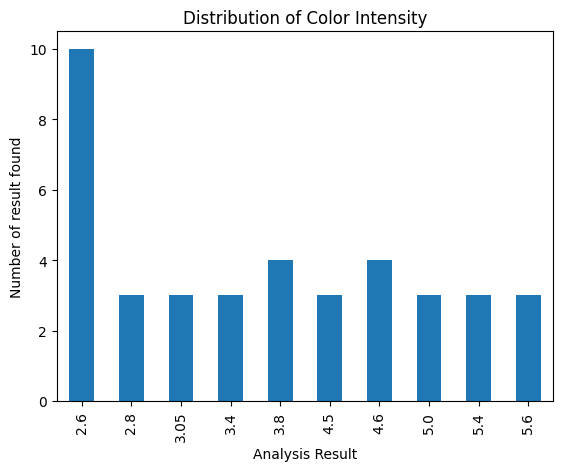

In [412]:
# plot distribution of the 'Color.int' column
color_distribution.plot.bar(xlabel="Analysis Result", ylabel="Number of result found", grid=False, title="Distribution of Color Intensity");

**Analysis:**

A wine's color intensity serves as an indicator of its richness and boldness. Wines that are more intense showcase deeper and more saturated colors, in contrast to those that are less intense, which tend to have lighter and more subdued shades (The Wine Cellarage, 2023).

The most frequent color intensity observed from the plot is 2.6, indicating that most of the wines in the dataset have lower color intensity. This suggests that these wines likely have a lighter color, which could be associated with factors such as grape variety, winemaking process, or age.


##### 2.1.4 Column 'Hue'

In [413]:
# summarize
print('Summarize: ')
print(fill["Hue"].describe(), "\n")
print('Unique value: ' ,fill["Hue"].unique())

Summarize: 
count    178.000000
mean       0.957449
std        0.228572
min        0.480000
25%        0.782500
50%        0.965000
75%        1.120000
max        1.710000
Name: Hue, dtype: float64 

Unique value:  [1.04  1.05  1.03  0.86  1.02  1.06  1.08  1.01  1.25  1.17  1.15  1.2
 1.28  1.07  1.13  1.23  0.96  1.09  1.11  1.12  0.92  1.19  1.1   1.18
 0.89  0.95  0.91  0.88  0.82  0.87  1.24  0.98  0.94  1.22  1.45  0.906
 1.36  1.31  0.99  1.38  1.16  0.84  0.79  1.33  1.    1.42  1.27  0.8
 0.75  0.9   0.93  1.71  0.7   0.73  0.69  0.97  0.76  0.74  0.66  0.78
 0.81  0.77  0.65  0.6   0.58  0.54  0.55  0.57  0.59  0.48  0.61  0.56
 0.67  0.68  0.85  0.72  0.62  0.64 ]


In [414]:
# distribution of the 'Hue' column
hue_distribution = fill["Hue"].value_counts().nlargest(10).sort_index()
hue_distribution

Hue
0.57    5
0.75    4
0.89    5
0.96    5
1.04    8
1.05    4
1.12    6
1.19    4
1.23    7
1.25    5
Name: count, dtype: int64

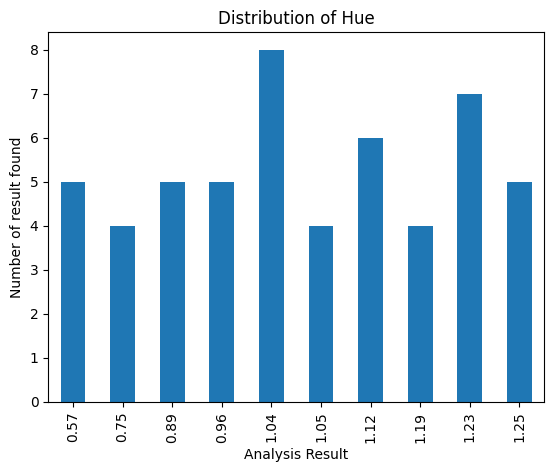

In [494]:
# plot distribution of the 'Hue' column
hue_distribution.plot.bar(xlabel="Analysis Result", ylabel="Number of result found", grid=False, title="Distribution of Hue");

**Analysis:**

The hue of wine refers to its color. When describing it, focus solely on the true tone, irrespective of its intensity, clarity through the glass, or the width of the rim. For white wines, potential hues include green, straw, yellow, gold, amber, or brown. In the case of rosé or red wines, terms such as salmon, pink, ruby, purple, garnet, and tawny are appropriate for characterizing the wine's hue (The Wine Cellarage, 2023).

The analysis of hue in the plot reveals a diverse range of colors, suggesting a blend of different grape varieties and potential variations in winemaking techniques. The data indicates a prevalence of wines with higher hue values, implying a significant number of wines with deeper, richer color characteristics.

##### 2.1.5 Column 'OD'

In [416]:
# summarize
print('Summarize: ')
print(fill["OD"].describe(), "\n")
print('Unique value: ' ,fill["OD"].unique())

Summarize: 
count    178.000000
mean       2.618652
std        0.706378
min        1.270000
25%        1.970000
50%        2.780000
75%        3.170000
max        4.000000
Name: OD, dtype: float64 

Unique value:  [3.92 3.4  3.17 3.45 2.93 2.85 3.58 3.55 2.82 2.9  2.73 3.   2.88 2.65
 2.57 3.36 3.71 3.52 4.   3.63 3.82 3.2  3.22 2.77 3.59 2.71 2.87 3.47
 2.78 2.51 2.69 3.53 3.38 3.56 3.35 3.33 3.44 2.75 3.1  2.91 3.37 3.26
 3.03 3.31 2.84 1.82 1.67 1.59 2.46 2.23 2.3  3.18 3.48 1.93 3.07 3.16
 3.5  3.13 2.14 2.48 2.52 2.31 3.12 3.14 2.72 2.01 3.08 2.26 3.21 2.27
 2.06 3.3  2.96 2.63 2.74 2.83 2.44 3.57 2.42 3.02 2.81 2.5  3.19 2.12
 3.05 3.39 3.69 3.64 3.28 1.29 1.42 1.36 1.51 1.58 1.27 1.69 2.15 2.47
 2.05 2.   1.68 1.33 1.86 1.62 1.3  1.47 1.55 1.48 1.64 1.73 1.96 1.78
 2.11 1.75 1.56 1.8  1.92 1.83 1.71 1.74 1.6 ]


In [417]:
# distribution of the 'OD' column
od_distribution = fill["OD"].value_counts().nlargest(10).sort_index()
od_distribution

OD
1.33    3
1.56    3
1.82    4
2.31    3
2.77    3
2.78    4
2.87    6
2.96    3
3.00    4
3.17    3
Name: count, dtype: int64

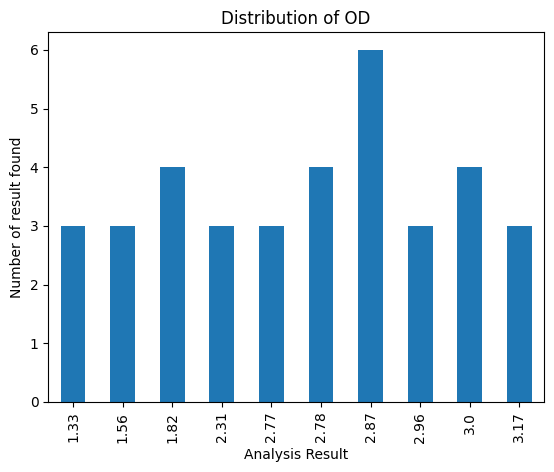

In [418]:
# plot distribution of the 'OD' column
od_distribution.plot.bar(xlabel="Analysis Result", ylabel="Number of result found", grid=False, title="Distribution of OD");

**Analysis:**

A higher OD280/OD315 absorbance ratio indicates an increased level of protein purity. Additionally, as the OD280/OD315 ratio increases, the flavor profile of the wine tends to become more bitter (Jana, D. K., et al, 2023).

The results demonstrated that most wines had a high OD280/OD315 ratio. This is indicative of a greater protein concentration within the wine, which tends to impart a bitter taste to the overall flavor profile.

##### 2.1.6 Column 'Proline'

In [419]:
# summarize
print('Summarize: ')
print(fill["Proline"].describe(), "\n")
print('Unique value: ' ,fill["Proline"].unique())

Summarize: 
count     178.000000
mean      736.314607
std       315.751551
min       278.000000
25%       504.000000
50%       645.000000
75%       961.750000
max      1680.000000
Name: Proline, dtype: float64 

Unique value:  [1065. 1050. 1185. 1480.  735. 1450. 1290. 1295. 1045. 1510. 1280. 1320.
 1150. 1547. 1310. 1130. 1680.  845.  780.  770. 1035.  520.  830. 1195.
 1285.  915. 1515.  990. 1235. 1095.  880. 1105. 1020.  760.  795.  680.
  885. 1080.  985. 1060. 1260. 1265. 1190. 1375. 1120.  970. 1270.  450.
  630.  420.  355.  502.  510.  750.  718.  870.  410.  472.  886.  428.
  392.  500.  463.  278.  714.  515.  495.  562.  625.  480.  290.  345.
  937.  660.  406.  710.  438.  415.  672.  315.  488.  312.  325.  607.
  434.  385.  407.  372.  564.  465.  365.  380.  378.  352.  466.  342.
  580.  530.  560.  600.  650.  695.  720.  590.  550.  855.  425.  640.
  725.  620.  570.  675.  615.  685.  740.  835.  840.]


In [420]:
# distribution of the 'Proline' column
proline_distribution = fill["Proline"].value_counts().nlargest(10).sort_index()
proline_distribution

Proline
495.0      3
510.0      3
520.0     12
562.0      3
625.0      4
630.0      4
660.0      3
680.0      5
750.0      4
1035.0     3
Name: count, dtype: int64

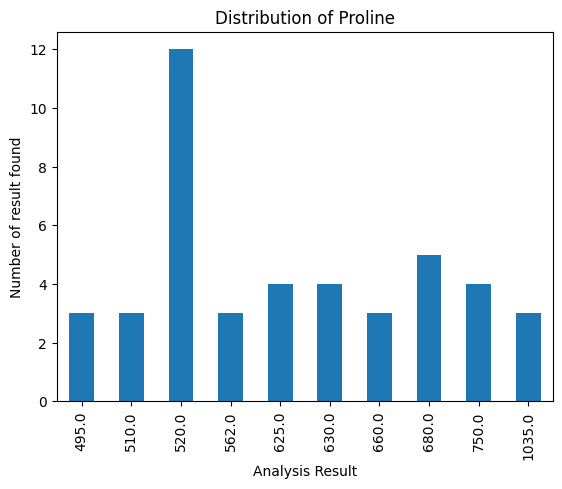

In [421]:
# plot distribution of the 'Proline' column
proline_distribution.plot.bar(xlabel="Analysis Result", ylabel="Number of result found", grid=False, title="Distribution of Proline");

**Analysis:**

Proline plays an essential role in the nutritional profile and flavor characteristics of wine, serving as the predominant amino acid present in grape juice and red wine. Its concentration is influenced by various viticultural practices and winemaking techniques, making it significant for diagnostic purposes. Research indicates that proline can reduce bitterness and astringency while enhancing sweetness, viscosity, and the perception of red fruit flavors (Jana, D. K., et al, 2023). 

The majority of the wine samples analyzed exhibit proline concentrations ranging from 500 to 700 mg/L. There are relatively few samples with proline levels below 500 mg/L and an even smaller number with levels exceeding 800 mg/L. This indicates that the proline level distribution within this sample is somewhat skewed towards the moderate range.


#### 2.2 Bivariate EDA

In [422]:
fill.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [423]:
# correlation heatmap
correlation_data = fill[["Wine", "Alcohol", "Color.int", 
                              "Hue", "OD", "Proline"]]

correlation_data.corr().style.background_gradient(cmap='YlOrRd')

,Wine,Alcohol,Color.int,Hue,OD,Proline
Wine,1.000000,-0.322517,0.275230,-0.608251,-0.785449,-0.620785
Alcohol,-0.322517,1.000000,0.526560,-0.072605,0.074095,0.626320
Color.int,0.275230,0.526560,1.000000,-0.514344,-0.429862,0.308767
Hue,-0.608251,-0.072605,-0.514344,1.000000,0.551549,0.220667
OD,-0.785449,0.074095,-0.429862,0.551549,1.000000,0.280060
Proline,-0.620785,0.626320,0.308767,0.220667,0.280060,1.000000


**Heatmap Analysis:**

The heatmap reveals several key correlations among the variables in the wine dataset:

Alcohol and Proline: There is a strong positive correlation between alcohol and proline content, with a correlation coefficient of approximately 0.63. This suggests that wines with higher alcohol content tend to have higher levels of proline. Proline is an amino acid that contributes to the flavor and stability of wine, and its correlation with alcohol content might be indicative of the wine's overall richness.

Alcohol and Color Intensity: The alcohol content also shows a moderate positive correlation with color intensity, with a correlation coefficient of about 0.53. This indicates that wines with higher alcohol content may have deeper color intensity.

Hue and OD (Optical Density): There is a moderate positive correlation between hue and optical density, with a correlation coefficient of approximately 0.55. This suggests that wines with a stronger color hue tend to have higher optical density.

In [424]:
!pip install seaborn
import seaborn as sns

!pip install squarify
import squarify 
from matplotlib import pyplot as plt

import numpy as np


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


##### 2.2.1 Alcohol and Proline

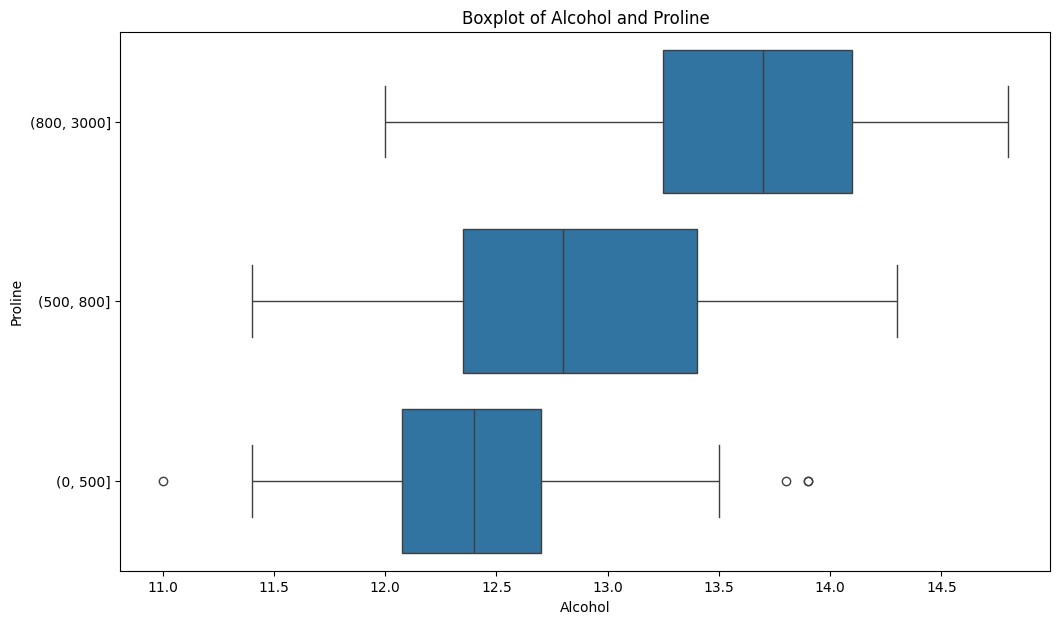

In [425]:

# Rounding the 'Alcohol'columns
fill['Alcohol'] = fill['Alcohol'].round(1)
# Binning Proline
fill['Proline_Binned'] = pd.cut(fill['Proline'], bins=[0, 500, 800, 3000])

# Create the boxplot with rounded values
plt.figure(figsize=(12, 7))
sns.boxplot(data=fill, x="Alcohol", y="Proline_Binned", orient="h")
plt.gca().invert_yaxis()  # Invert the y-axis
plt.title("Boxplot of Alcohol and Proline")
plt.xlabel("Alcohol")
plt.ylabel("Proline")
plt.show()

**Analysis:**

The boxplot indicates a positive correlation between the alcohol content and proline levels in wine, revealing that wines with elevated proline levels tend to possess higher alcohol content. 


Wines with proline concentrations between 800 and 3000 mg/L generally exhibit higher alcohol content, with an average near 14.0%. The proline range of 500 to 800 mg/L shows the highest degree of variability, while the lowest range (0–500 mg/L) maintains a consistent alcohol level of approximately 12.5%. 

##### Color and Alcohol

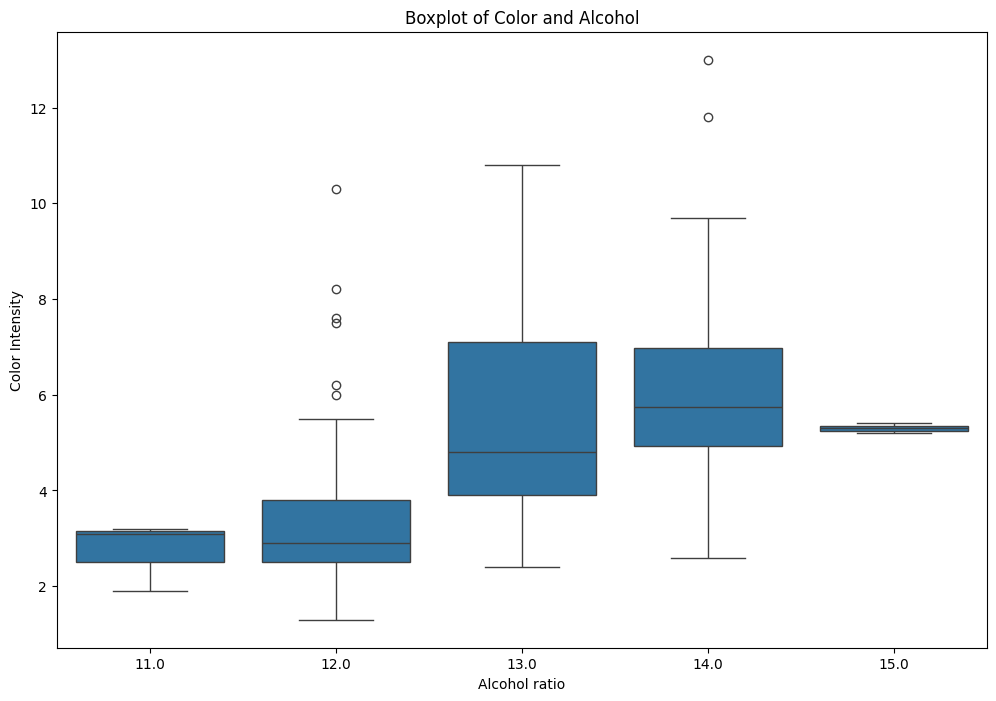

In [426]:

# Rounding the 'Color.Int' column
fill['Color.int'] = fill['Color.int'].round(1)
fill['Alcohol'] = fill['Alcohol'].round(0)

# Create the boxplot for Wine and Color.Int
plt.figure(figsize=(12, 8))
sns.boxplot(data=fill, y="Color.int", x="Alcohol", orient="v")
plt.title("Boxplot of Color and Alcohol")
plt.ylabel("Color Intensity")
plt.xlabel("Alcohol ratio")
plt.show()


**Analysis:**

As the alcohol ratio increases, the color intensity of the wine tends to show more variation. For example, wines with an alcohol ratio of around 11.0 and 12.0 have lower color intensity and less variation, while those with alcohol ratios of 13.0 and 14.0 show a wider range of color intensity values.

Wines with the highest alcohol ratio (15.0) have a very narrow range for color intensity, suggesting that these wines are more consistent in their color attributes compared to wines with lower alcohol content.

#### Hue and OD

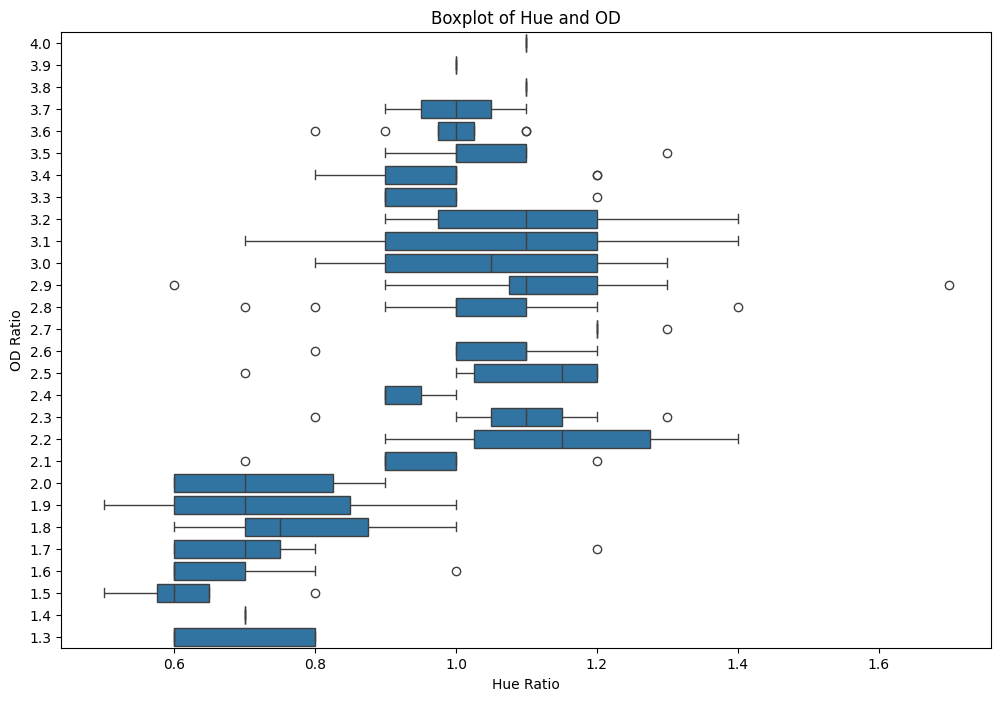

In [427]:
fill['Hue'] = fill['Hue'].round(1)
fill['OD'] = fill['OD'].round(1)

# Creating the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=fill, x="Hue", y="OD", orient="h")
plt.gca().invert_yaxis()  # Invert the y-axis
plt.title("Boxplot of Hue and OD")
plt.xlabel("Hue Ratio")
plt.ylabel("OD Ratio")
plt.show()


**Analysis:**

Within the hue ratio range of 0.9 to 1.1, there exists a concentration of elevated optical density (OD) ratios, specifically between 2.8 and 3.6. This indicates that wines characterized by a moderate hue ratio are likely to possess a higher optical density. Near a hue ratio of 1.0, there is considerable variability in OD ratios, with values spanning from approximately 2.0 to 3.5. This observation implies that wines with this particular hue ratio display a broader spectrum of optical densities. Conversely, at hue ratios exceeding 1.2, the variability in OD ratios diminishes, suggesting that wines with higher hue ratios tend to exhibit more uniform optical densities, although the number of samples is limited.

### (QUESTION 3) Mean and Standard Deviation

In [428]:
import pandas as pd
import numpy as np
import tabulate

# Load the data
data = fill.copy()

# Calculate mean and standard deviation for each component for each cultivator
cultivators = data['Wine'].unique()
components = ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
               'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
               'OD', 'Proline']

# Create separate tables for each wine
for i, cultivator in enumerate(cultivators):
    cultivator_data = data[data['Wine'] == cultivator]
    results = []
    for component in components:
        mean = np.mean(cultivator_data[component])
        std = np.std(cultivator_data[component])
        results.append([component, mean, std])
    
    # Create a table to report the findings
    table = tabulate.tabulate(results, headers=['Component', 'Mean', 'Standard Deviation'], tablefmt='fancy_grid')
    print(f"Wine cultivator {i+1}:")
    print(table)
    print()

Wine cultivator 1:
╒══════════════════════╤════════════╤══════════════════════╕
│ Component            │       Mean │   Standard Deviation │
╞══════════════════════╪════════════╪══════════════════════╡
│ Alcohol              │   13.7288  │            0.547119  │
├──────────────────────┼────────────┼──────────────────────┤
│ Malic.acid           │    2.01068 │            0.682689  │
├──────────────────────┼────────────┼──────────────────────┤
│ Ash                  │    2.45559 │            0.225233  │
├──────────────────────┼────────────┼──────────────────────┤
│ Acl                  │   17.2034  │            2.52868   │
├──────────────────────┼────────────┼──────────────────────┤
│ Mg                   │  106.339   │           10.4096    │
├──────────────────────┼────────────┼──────────────────────┤
│ Phenols              │    2.81847 │            0.355408  │
├──────────────────────┼────────────┼──────────────────────┤
│ Flavanoids           │    2.98237 │            0.394111  │
├────

**Analysis**

Comparative Observations Between Wine Cultivators:

1. Alcohol Content: Cultivators 1 and 3 produce wines with higher average alcohol levels (13.72 and 13.15, respectively) compared to Cultivator 2 (12.29). This indicates that Cultivator 2's wines tend to have a lower alcohol concentration.

2. Malic Acid: Cultivator 3 has the highest average malic acid content (3.35), which is considerably greater than that of Cultivators 1 (2.01) and 2 (1.93). This suggests that wines from Cultivator 3 may have a sharper or more acidic taste.

3. Ash and Acl: The ash content remains relatively consistent among the three cultivators. However, Acl is highest in wines from Cultivator 3 (21.39) and lowest in those from Cultivator 1 (17.20).

4. Magnesium (Mg): Wines from Cultivator 1 contain the most magnesium (106.34), while Cultivator 2’s wines have the least (94.46).

5. Phenols and Flavanoids: Cultivator 1 produces wines with the highest total phenols (2.82) and flavanoids (2.98), contributing to antioxidant properties and bitterness. On the other hand, Cultivator 3’s wines have the lowest phenol (1.69) and flavanoid (0.83) levels, which may result in a different flavor profile.

6. Nonflavanoid Phenols: Cultivator 3 has the highest average nonflavanoid phenol content (0.45), which may affect the wine's bitterness and stability. In contrast, Cultivator 1 has the lowest level (0.29).

7. Proanthocyanins: Cultivator 1 leads in proanthocyanins (1.90), while Cultivator 3 has the lowest amount (1.16). This can influence the wine's color and astringency.

8. Color Intensity and Hue: Cultivator 3 produces wines with the most intense color (7.34), whereas Cultivator 2's wines have the least intensity (3.05). However, Cultivator 3’s wines have the lowest hue (0.69), indicating a deeper red color, while the hues of Cultivators 1 and 2 are similar (1.06 and 1.05, respectively).

9. Optical Density (OD): Wines from Cultivator 1 have the highest OD (3.16), whereas Cultivator 3's wines have the lowest (1.69). Higher OD values often correlate with darker wines, more pigments, and higher phenolic concentrations.

10. Proline: Cultivator 1’s wines have the highest proline content (1100.54), which is significantly more than that of Cultivators 2 (510.86) and 3 (624.47).

**Conclusion:** The analysis highlights substantial differences among the wine cultivators across various chemical components. Cultivator 1's wines stand out for their higher alcohol content, phenolic compounds, and proline levels. Cultivator 3 emphasizes wines with high acidity and color intensity but lower phenolic content. Cultivator 2, produces wines with lower alcohol content and moderate values across most components.

### (QUESTION 4) Correlation

Covariance Matrix for Wine 1:
                        Alcohol  Malic.acid       Ash         Acl          Mg  \
Alcohol                0.304500   -0.063261 -0.010698   -0.347341    0.524547   
Malic.acid            -0.063261    0.474100  0.004101    0.324860    0.573387   
Ash                   -0.010698    0.004101  0.051604    0.305739    0.912382   
Acl                   -0.347341    0.324860  0.305739    6.504471    8.945383   
Mg                     0.524547    0.573387  0.912382    8.945383  110.227937   
Phenols                0.048200   -0.015263 -0.000190   -0.196702    0.932595   
Flavanoids             0.085999   -0.052352 -0.006362   -0.282922    0.514699   
Nonflavanoid.phenols   0.002759   -0.004310  0.007414    0.042845    0.174483   
Proanth                0.039641   -0.022927 -0.013619   -0.154256   -0.255456   
Color.int              0.190006   -0.240725 -0.051779   -0.648539    1.768527   
Hue                    0.014962   -0.033331  0.006122    0.000330   -0.120427  

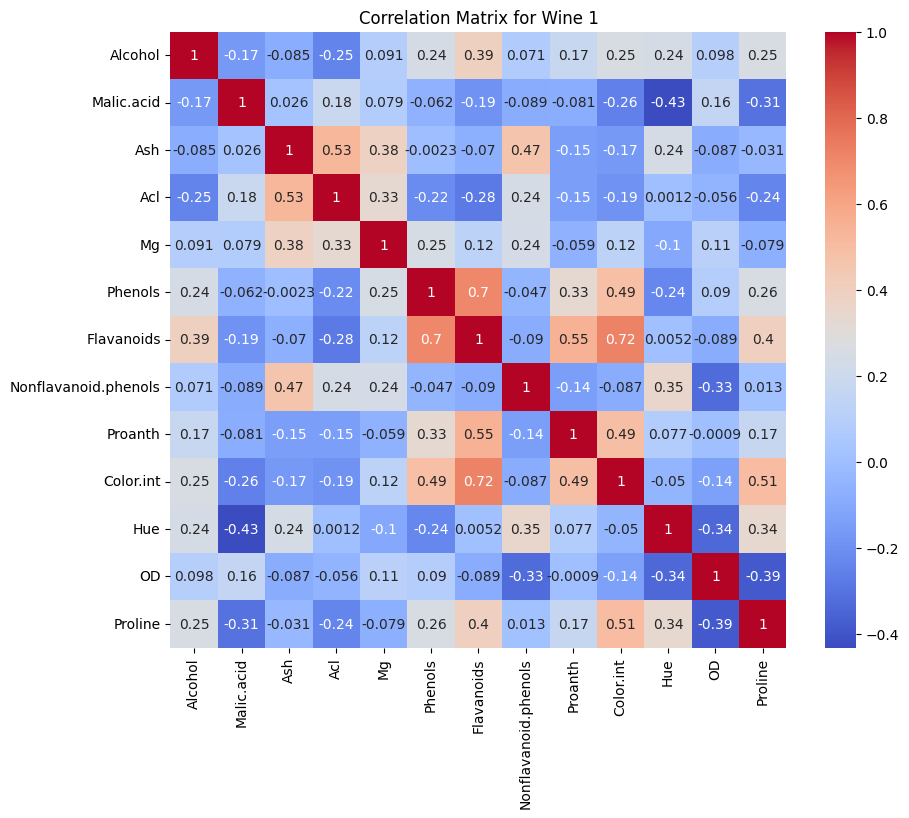

Covariance Matrix for Wine 2:
                       Alcohol  Malic.acid       Ash        Acl          Mg  \
Alcohol               0.359155    0.020176 -0.021056   0.064437   -0.637324   
Malic.acid            0.020176    1.017424  0.046873   0.830884   -1.269654   
Ash                  -0.021056    0.046873  0.098135   0.721675    0.669660   
Acl                   0.064437    0.830884  0.721675  10.902236    1.394190   
Mg                   -0.637324   -1.269654  0.669660   1.394190  277.322183   
Phenols              -0.041268    0.024180  0.019125   0.250347    0.707934   
Flavanoids           -0.017218    0.080600  0.071191   0.773501   -0.023351   
Nonflavanoid.phenols -0.006338    0.016130  0.011506   0.072131   -0.388075   
Proanth              -0.077430    0.129708  0.007559   0.232560    3.051473   
Color.int             0.171127   -0.163936  0.018746  -0.160998    0.921948   
Hue                  -0.006338   -0.079697 -0.001508  -0.037758    0.545892   
OD                   -

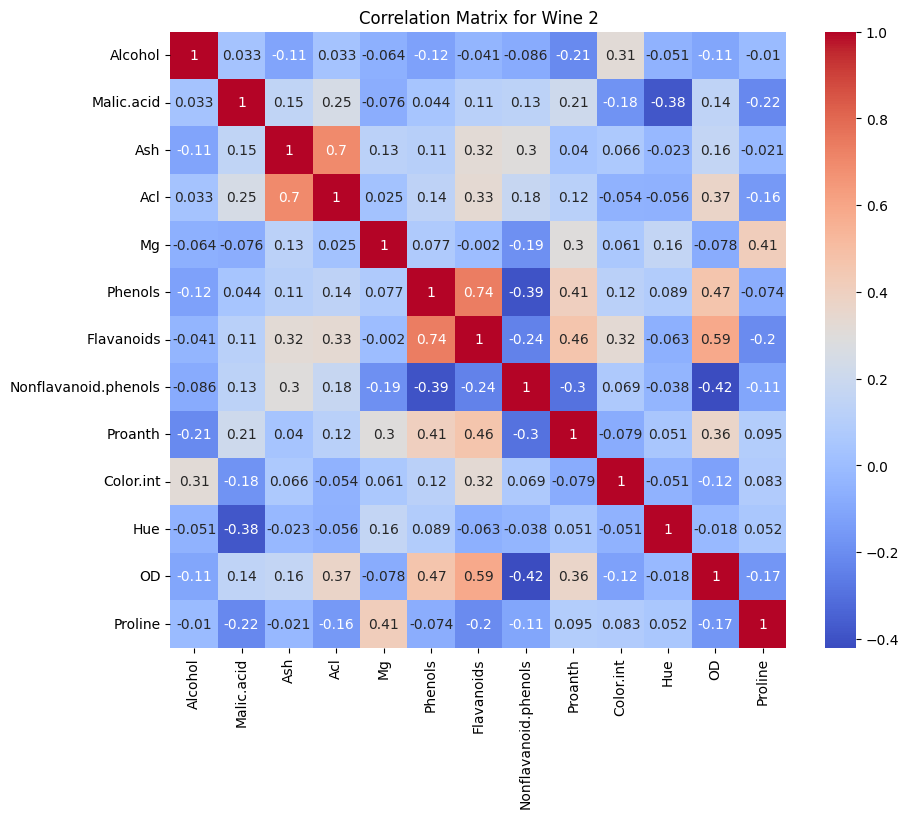

Covariance Matrix for Wine 3:
                        Alcohol  Malic.acid       Ash       Acl          Mg  \
Alcohol                0.477336    0.010287  0.020370  0.124884   -0.438483   
Malic.acid             0.010287    1.189494  0.000416  0.187481   -2.397114   
Ash                    0.020370    0.000416  0.034304  0.293742    0.387784   
Acl                    0.124884    0.187481  0.293742  5.042784    3.510407   
Mg                    -0.438483   -2.397114  0.387784  3.510407  117.246068   
Phenols                0.018599   -0.070489  0.030328  0.296591   -0.287345   
Flavanoids             0.014653   -0.115101  0.021958  0.307375    1.839917   
Nonflavanoid.phenols  -0.001471    0.020380 -0.000364 -0.008064   -0.688927   
Proanth                0.060407   -0.112304  0.013163  0.271247    0.546628   
Color.int              0.315264   -0.368580  0.064286  1.228538    3.471924   
Hue                    0.000971   -0.000105  0.003503 -0.015911   -0.046115   
OD                    

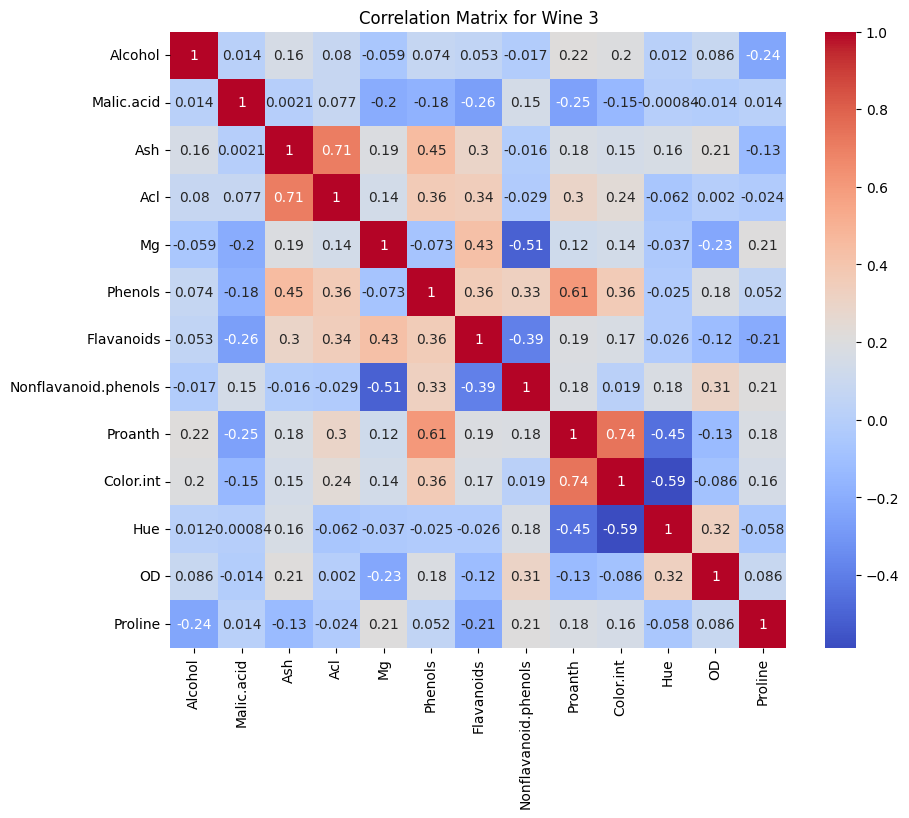

In [429]:
# Load the data
data = fill.copy()

# Calculate covariance and correlation for each cultivator
cultivators = data['Wine'].unique()
components = ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
               'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
               'OD', 'Proline']

for i, cultivator in enumerate(cultivators):
    cultivator_data = data[data['Wine'] == cultivator][components]
    
    # Calculate the covariance matrix
    cov_matrix = cultivator_data.cov()
    
    # Print the covariance table
    print(f"Covariance Matrix for Wine {i+1}:")
    print(cov_matrix)
    print()
    
    # Calculate the correlation matrix
    corr_matrix = cov_matrix / np.outer(cultivator_data.std(), cultivator_data.std())
    
    # Create a heatmap to visualize the correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
    plt.title(f"Correlation Matrix for Wine {i+1}")
    plt.show()

**Correlation Analysis for Wine Cultivator 1**

1. Strong Positive Correlations:
- Flavanoids and Phenols (0.7): This strong positive relationship indicates that as flavanoid concentrations rise, phenol concentrations also tend to increase. This is logical since flavanoids are a subset of phenolic compounds.
 Flavanoids and Proanth (0.55): A moderate-to-strong correlation indicates that wines with higher flavanoid content also tend to have higher proanth levels, both of which are phenolic compounds.
- Color Intensity and Proline (0.51): This correlation suggests that wines with deeper color intensity often have higher proline levels

2. Strong Negative Correlations:
- Proline and OD280/OD315 (Optical Density) (-0.39): This negative correlation indicates that higher proline levels correspond to lower optical density, potentially reflecting a balance between sweetness and phenolic concentration.
- Alcohol and Ash Alcalinity (Acl) (-0.34): This negative correlation indicates that wines with higher alcohol content tend to have lower ash alkalinity.
- Malic Acid and Flavanoids (-0.19): Although weaker, this negative correlation suggests that wines with higher malic acid tend to have lower flavanoid levels, affecting the taste profile—malic acid contributes acidity, while flavanoids add bitterness and astringency.

3. Moderate Correlations:
- Alcohol and Proline (0.39): This positive correlation suggests that wines with higher alcohol content also tend to have more proline, hinting that sweeter wines may also have higher alcohol levels due to increased sugar for fermentation.
- Hue and Proline (0.32): This positive correlation suggests that wines with greater hue (reflecting more intense color) often have higher proline levels, hinting at a link between color and sweetness.

4. Weak Correlations:
- Magnesium (Mg) and OD280/OD315 (0.11): A very weak positive correlation suggests that magnesium levels have minimal effect on optical density readings.
- Nonflavanoid Phenols and Flavanoids (-0.14): This weak negative correlation suggests little to no relationship between nonflavanoid phenols and flavanoids, implying that these two types of phenols vary independently.
- Color Intensity and Ash (-0.19): The weak correlation suggests that ash content does not significantly influence the wine’s color intensity.

Conclusion: There is a strong connection between phenols, flavanoids, and proanthocyanins, as expected due to their chemical similarities and influence on the wine's flavor and color. The link between alcohol and proline is noteworthy, as it indicates that wines with higher sweetness (more proline) also tend to have higher alcohol content, possibly due to increased sugar availability during fermentation.

**Correlation Analysis for Wine Cultivator 2**

1. Strong Positive Correlations:
- Phenols and Flavanoids (0.74): A strong correlation between these variables indicates that wines with higher total phenol levels also tend to have higher flavanoid content.
- Ash and Ash Alcalinity (Acl) (0.7): This strong positive relationship suggests that as ash content increases, the alkalinity of the ash also rises, consistent with earlier findings.
- Flavanoids and Optical Density (OD280/OD315) (0.59): This indicates that flavanoids significantly impact optical density, likely due to their influence on the wine's color and transparency.
- Phenols and Proanthocyanins (0.49): This moderate positive correlation indicates that higher phenol levels are generally associated with higher proanth levels.

2. Moderate Positive Correlations:
- Color Intensity and Proanth (0.47): A moderate correlation suggests that wines with more intense color also tend to have higher proanth levels, contributing to the wine's pigmentation.
- Phenols and Optical Density (OD280/OD315) (0.47): As phenol content increases, optical density also tends to rise, reflecting the role of phenols in affecting wine color and clarity.
- Flavanoids and Proanth (0.46): This positive relationship indicates that wines with higher flavanoid content also tend to have higher proanthocyanins.

3. Strong Negative Correlations:
- Flavanoids and Malic Acid (-0.2): This negative correlation suggests that wines higher in flavanoids tend to have lower malic acid levels, influencing the wine's balance between bitterness and acidity.
- Proanth and Flavanoids (-0.3): This inverse relationship suggests that higher flavanoid levels are associated with lower proanth.

4. Weak Correlations:
- Hue and Phenols (0.14): A very weak positive correlation indicates that the wine's hue (color) is not significantly influenced by phenolic content.
- Alcohol and Ash (-0.21): This weak negative correlation indicates that alcohol content is not strongly influenced by ash (mineral) content in the wine.
- Malic Acid and Proline (-0.22): This weak negative relationship suggests little interaction between these two components.

Conclusion: Similar to previous findings, strong correlations among phenols, flavanoids, and proanthocyanins emphasize their joint role in shaping the wine's flavor and color; Moderate correlations between optical density and both flavanoids and phenols underscore their influence on the wine's color and visual clarity; The consistent relationship between ash content and ash alkalinity across both analyses suggests this could serve as a reliable indicator of mineral content in wine analysis.

**Correlation Analysis for Wine Cultivator 3**

1. Strong Positive Correlations:
- Proanth and Color Intensity (0.74): A strong positive correlation indicates that higher levels of proanthocyanins are associated with greater color intensity, as these compounds play a key role in the wine's coloration.
- Ash and Alcalinity of Ash (Acl) (0.71): Consistently observed across all wine datasets, this positive correlation reflects the increase in alkalinity as ash content rises.

2. Moderate Positive Correlations:
- Phenols and Flavanoids (0.61): This strong correlation shows that wines with higher total phenolic content also have more flavanoids, a pattern consistent across all wine datasets, underscoring the close connection between these two phenolic compounds.
- Phenols and Proanthocyanins (0.61): This strong positive relationship suggests that higher phenolic content is linked to increased proanthocyanins.
- Proanth and Phenols (0.61): The moderate to strong correlation further emphasizes that proanthocyanins are an integral part of the total phenolic content in the wine.
  
3. Strong Negative Correlations:
- Hue and Color Intensity (-0.59): A strong inverse relationship shows that as the hue shifts towards red or brown tones, color intensity decreases.
- Nonflavanoid Phenols and Flavanoids (-0.39): This moderate negative correlation indicates that nonflavanoid phenols and flavanoids vary inversely, suggesting they contribute differently to the wine's overall profile.
- Magnesium (Mg) and Phenols (-0.51): A negative correlation implies that higher magnesium levels correspond with lower phenolic content.
- Color Intensity and Flavanoids (-0.39): This moderate negative correlation suggests that wines with more intense color tend to have lower flavanoid content.
  
4. Weak Correlations:
- Alcohol and Malic Acid (-0.087): A weak negative correlation indicates that alcohol content and malic acid are largely independent of one another and do not significantly influence each other.
- Optical Density (OD280/OD315) and Proline (-0.086): This very weak negative correlation suggests little to no relationship between these variables, indicating proline content has minimal impact on the wine's optical density.

Conclusion:
As with previous datasets, strong correlations among phenols, flavanoids, and proanthocyanins highlight their interconnected role in shaping the wine's flavor and color profile. The relationship between hue and color intensity suggests a complex interaction between these color traits.

**Plot Comparison**

1. **Phenols and Flavanoids:**
All three datasets display strong positive correlations between phenols and flavanoids. This consistent relationship indicates a close connection between these components in influencing the wine's chemical and sensory properties. Although Wine 3 shows a slightly weaker correlation, it remains significant.

3. **Ash and Acl:**
The correlation between ash and ash alkalinity is strong and stable across all datasets, with Wines 2 and 3 showing slightly stronger correlations than Wine 1. This robust relationship likely reflects the role of mineral content in the wines.

4. **Proanthocyanins and Color Intensity:**
While Wines 1 and 3 exhibit moderate to strong correlations between proanthocyanins and color intensity, Wine 2 shows a weaker correlation. This variability suggests differences in how proanthocyanins impact color intensity across different wine samples, with Wine 3 showing a particularly strong relationship, implying that proanthocyanins significantly influence color in this case.

5. **Phenols and Proanthocyanins:**
The relationship between phenols and proanth is moderately positive in Wines 1 and 2, but stronger in Wine 3. This suggests that in Wine 3, these components are more closely linked.

6. **Alcohol and Ash:**
Wines 1 and 2 show weak negative correlations between alcohol and ash, indicating a slight inverse relationship. However, Wine 3 displays a weak positive correlation, indicating a different interaction between these components.

7. **Hue and Color Intensity:**
The relationship between hue and color intensity varies significantly across the datasets. Wine 1 shows a weak positive correlation, while Wine 2 has a weak negative correlation, and Wine 3 demonstrates a strong negative correlation. This suggests the interplay between these color characteristics varies and could be influenced by factors like grape variety or aging.

8. **Flavanoids and Malic Acid:**
All three wines show weak negative correlations between flavanoids and malic acid, implying that wines with higher flavanoid content tend to have lower malic acid levels. This consistent trend may reflect an inverse relationship between sweetness and acidity in the wines.

9. **Nonflavanoid Phenols and Flavanoids:**
While Wines 1 and 2 show weak positive correlations between nonflavanoid phenols and flavanoids, Wine 3 displays a moderate negative correlation. This suggests an inverse relationship in Wine 3, where higher levels of nonflavanoid phenols are linked to lower flavanoid levels, potentially affecting bitterness and astringency differently in this sample.

**Summary:**
- Certain relationships, such as between phenols and flavanoids or ash and ash alkalinity, are consistent across all datasets, underscoring key interactions in the wine's composition.
- Other correlations, like those between hue and color intensity, or proanthocyanins and color intensity, vary notably between datasets, suggesting that these relationships depend on specific factors.
- Wine 3 displays some distinct correlations (e.g., stronger relationship between proanth and color intensity, and a negative correlation between nonflavanoid phenols and flavanoids), highlighting its unique characteristics that differentiate it from the other two wines.

#### Q5. k-means clustering

<b>Step 1 : </b> Decide on the number of clusters k to group objects into

In [475]:
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = fill.copy()

# Select features for clustering
features = ['Alcohol', 'Color.int', 'Hue', 'OD', 'Proline']

# Standardize the data
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)

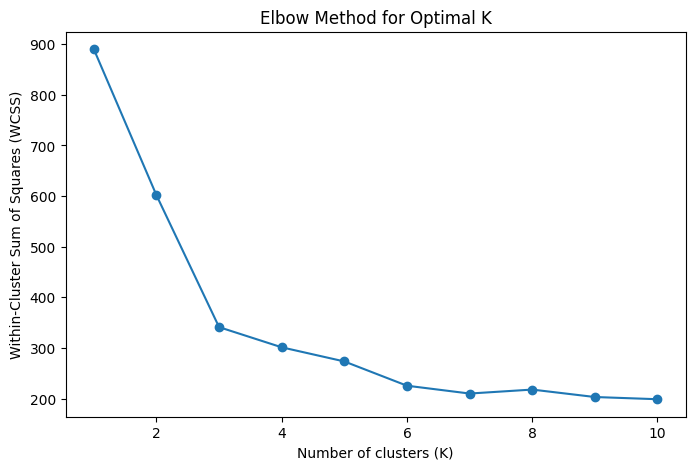

In [476]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for different numbers of clusters
"""wcss is indicator in data clustering that evaluates the integrity of the clusters generated. 
It computes the sum of the squared distances from each data point to the centroid of the cluster it belongs to."""

wcss = []
for i in range(1, 11):  # Checking K from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_standardized)
    wcss.append(kmeans.inertia_)  # WCSS

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()


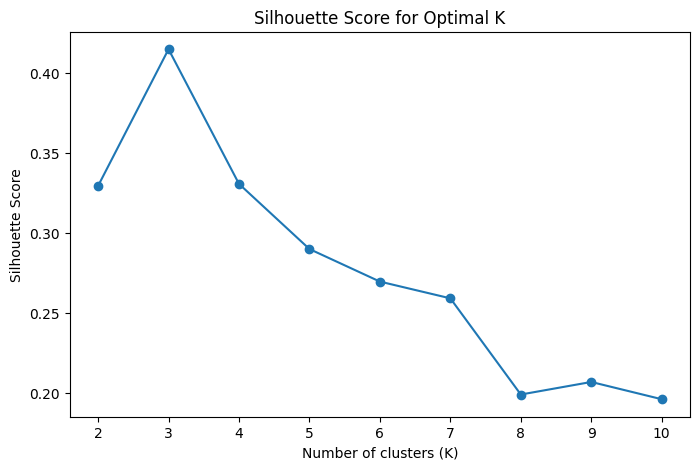

In [477]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for different numbers of clusters
silhouette_scores = []
for i in range(2, 11):  # Silhouette is not defined for K=1
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_standardized)
    cluster_labels = kmeans.predict(df_standardized)
    silhouette_scores.append(silhouette_score(df_standardized, cluster_labels))

# Plot the Silhouette Score graph
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()


In [478]:
# Decide on the number of clusters
K = 3

<b> Step 2 : </b> K centroids are randomly assigned

Initial Centroids: 
      Alcohol  Color.int       Hue        OD   Proline
19   0.799220  -1.020904  0.011190  1.052467  0.345183
45   1.504646   0.121913 -0.383670  1.009877  1.091538
140 -0.079470  -0.155133 -0.822404 -0.438182 -0.432933


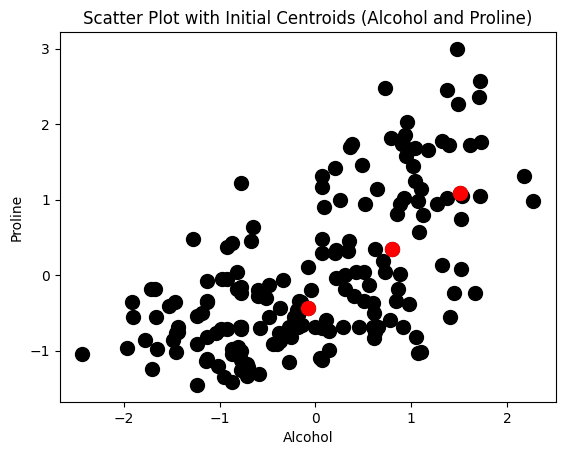

In [479]:
# Select random observations as centroids
Centroids = df_standardized.sample(n=K, random_state=42)

print("Initial Centroids: ")
print(Centroids)

# Visualize data points, with red points representing centroids
plt.scatter(df_standardized["Alcohol"], df_standardized["Proline"], s=100, c='black')
plt.scatter(Centroids["Alcohol"], Centroids["Proline"], s=100, c='red')
plt.xlabel('Alcohol')
plt.ylabel('Proline')
plt.title("Scatter Plot with Initial Centroids (Alcohol and Proline)")
plt.show()

<b> Step 3 : </b> Calculate the distance between each instance and the center of each cluster

In [480]:
# Function to calculate the Euclidean distance between an observation and the centroids
def distance(obs):
    d = np.sqrt(((obs - Centroids) ** 2).sum(axis=1))  
    return d.idxmin()  

# Apply the function to the entire dataset
clusters = df_standardized.apply(distance, axis=1)

<b> Step 4 : </b> If the object is closer to the center of another cluster than the one it is currently assigned to, it is reassigned to the closer cluster

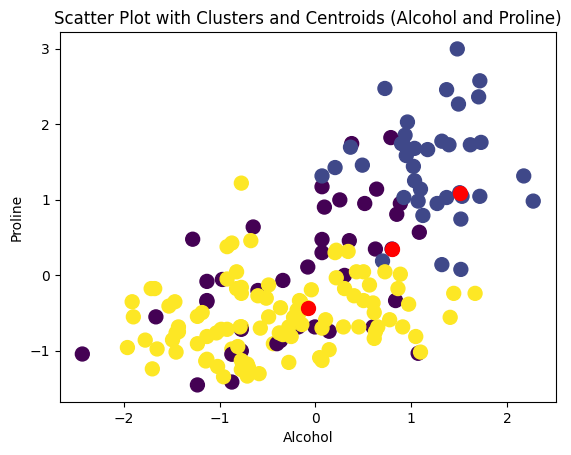

In [481]:
# Plot the cluster assignments
plt.scatter(df_standardized["Alcohol"], df_standardized["Proline"], s=100, c=clusters)
plt.scatter(Centroids["Alcohol"], Centroids["Proline"], s=100, c='red')
plt.xlabel('Alcohol')
plt.ylabel('Proline')
plt.title("Scatter Plot with Clusters and Centroids (Alcohol and Proline)")
plt.show()

<b> Step 5 : </b> Recalculate the centroids

In [482]:
# Recalculate the centroids by averaging the values of the points assigned to each cluster
Centroids = df_standardized.groupby(clusters).mean()

print("New Centroids: ")
print(Centroids)


New Centroids: 
      Alcohol  Color.int       Hue        OD   Proline
19  -0.161151  -0.654791  0.922660  0.724169 -0.003381
45   1.202088   0.492714  0.444151  0.759194  1.461122
140 -0.392333   0.074685 -0.537841 -0.578161 -0.553874


**Repeat step 2 to 5 for other clusters**

Initial Centroids: 
      Alcohol  Color.int       Hue        OD   Proline
19   0.799220  -1.020904  0.011190  1.052467  0.345183
45   1.504646   0.121913 -0.383670  1.009877  1.091538
140 -0.079470  -0.155133 -0.822404 -0.438182 -0.432933


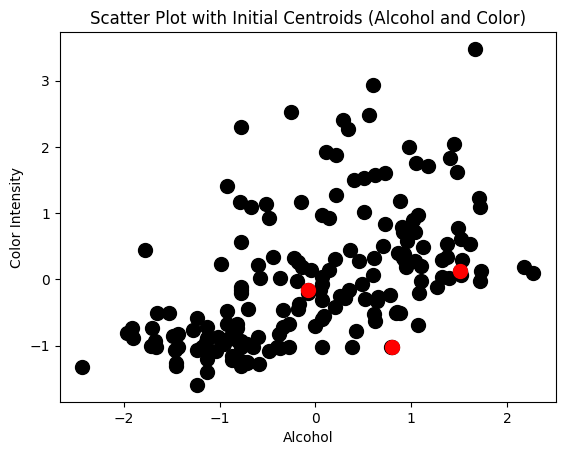

In [483]:
# Select random observations as centroids
Centroids = df_standardized.sample(n=K, random_state=42)

print("Initial Centroids: ")
print(Centroids)

# Visualize data points, with red points representing centroids
plt.scatter(df_standardized["Alcohol"], df_standardized["Color.int"], s=100, c='black')
plt.scatter(Centroids["Alcohol"], Centroids["Color.int"], s=100, c='red')
plt.xlabel('Alcohol')
plt.ylabel('Color Intensity')
plt.title("Scatter Plot with Initial Centroids (Alcohol and Color)")
plt.show()

In [484]:
# Function to calculate the Euclidean distance between an observation and the centroids
def distance(obs):
    d = np.sqrt(((obs - Centroids) ** 2).sum(axis=1))  # Axis=1 sums row-wise
    return d.idxmin()  # Returns index of the closest centroid

# Apply the function to the entire dataset
clusters = df_standardized.apply(distance, axis=1)

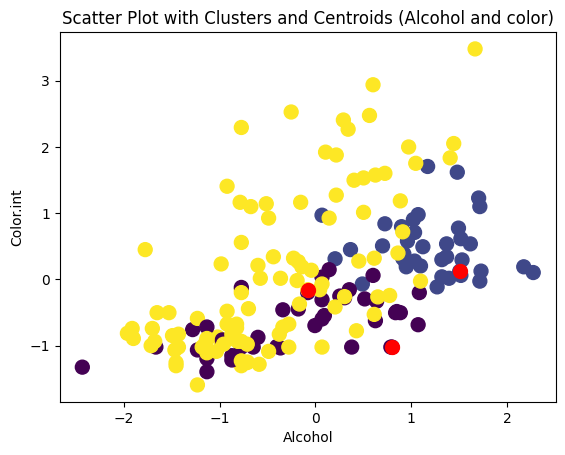

In [485]:
# Plot the cluster assignments
plt.scatter(df_standardized["Alcohol"], df_standardized["Color.int"], s=100, c=clusters)
plt.scatter(Centroids["Alcohol"], Centroids["Color.int"], s=100, c='red')
plt.xlabel('Alcohol')
plt.ylabel('Color.int')
plt.title("Scatter Plot with Clusters and Centroids (Alcohol and color)")
plt.show()

In [486]:
# Recalculate the centroids by averaging the values of the points assigned to each cluster
Centroids = df_standardized.groupby(clusters).mean()

print("New Centroids: ")
print(Centroids)


New Centroids: 
      Alcohol  Color.int       Hue        OD   Proline
19  -0.161151  -0.654791  0.922660  0.724169 -0.003381
45   1.202088   0.492714  0.444151  0.759194  1.461122
140 -0.392333   0.074685 -0.537841 -0.578161 -0.553874


Initial Centroids: 
      Alcohol  Color.int       Hue        OD   Proline
19   0.799220  -1.020904  0.011190  1.052467  0.345183
45   1.504646   0.121913 -0.383670  1.009877  1.091538
140 -0.079470  -0.155133 -0.822404 -0.438182 -0.432933


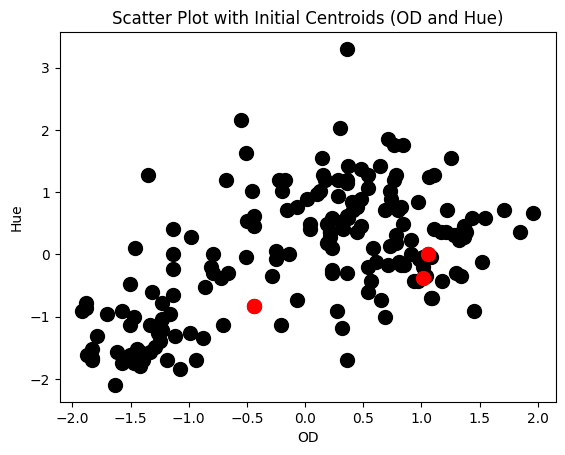

In [487]:
# Select random observations as centroids
Centroids = df_standardized.sample(n=K, random_state=42)

print("Initial Centroids: ")
print(Centroids)

# Visualize data points, with red points representing centroids
plt.scatter(df_standardized["OD"], df_standardized["Hue"], s=100, c='black')
plt.scatter(Centroids["OD"], Centroids["Hue"], s=100, c='red')
plt.xlabel('OD')
plt.ylabel('Hue')
plt.title("Scatter Plot with Initial Centroids (OD and Hue)")
plt.show()

In [488]:
# Function to calculate the Euclidean distance between an observation and the centroids
def distance(obs):
    d = np.sqrt(((obs - Centroids) ** 2).sum(axis=1))  # Axis=1 sums row-wise
    return d.idxmin()  # Returns index of the closest centroid

# Apply the function to the entire dataset
clusters = df_standardized.apply(distance, axis=1)

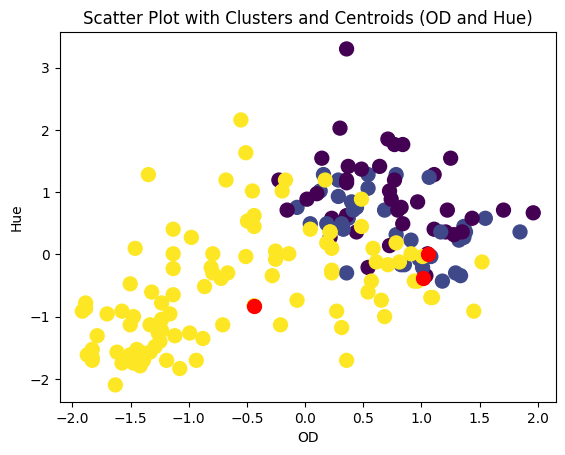

In [489]:
# Plot the cluster assignments
plt.scatter(df_standardized["OD"], df_standardized["Hue"], s=100, c=clusters)
plt.scatter(Centroids["OD"], Centroids["Hue"], s=100, c='red')
plt.xlabel('OD')
plt.ylabel('Hue')
plt.title("Scatter Plot with Clusters and Centroids (OD and Hue)")
plt.show()

In [490]:
# Recalculate the centroids by averaging the values of the points assigned to each cluster
Centroids = df_standardized.groupby(clusters).mean()

print("New Centroids: ")
print(Centroids)


New Centroids: 
      Alcohol  Color.int       Hue        OD   Proline
19  -0.161151  -0.654791  0.922660  0.724169 -0.003381
45   1.202088   0.492714  0.444151  0.759194  1.461122
140 -0.392333   0.074685 -0.537841 -0.578161 -0.553874


**Justification of the chosen K:**

* The "elbow" in the graph occurs at K = 3, indicating that using 3 clusters is likely the most optimal choice. Beyond this point, adding more clusters results in only marginal improvements in reducing WCSS.
* The highest Silhouette Score is observed at K = 3, with a value around 0.42. This suggests that dividing the data into 3 clusters provides the best structure, as the Silhouette Score reflects how closely objects fit within their own cluster compared to others. A higher score implies more clearly defined clusters.

**K-mean cluster limitation**

The scatter plot clusters display some separation between the data points, but they provide limited insight into the relationships between the variables. While general patterns can be observed, such as wines with higher alcohol content also having higher proline levels, the clusters alone don't clearly explain how the variables interact to form these groupings. To gain a more comprehensive understanding, additional analysis, like calculating correlations, would be necessary.

**Comparison to EDA**

The EDA illustrates the distribution of various features and suggests potential relationships between variables. For instance, the EDA for Alcohol and Proline indicates that wines with higher alcohol content tend to have higher proline levels. Scatterplots with clusters and centroids visually represent the groupings identified by the K-means algorithm. Comparing these clusters with the EDA helps us understand how the clusters correspond to feature distributions. For example, the scatterplot for Alcohol and Proline shows that the cluster has wines with lower alcohol and proline levels than the others, which is confirmed by the bivariate EDA showing lower median values for these features. Similar insights can be drawn when comparing cluster relationships with EDA for alcohol and color, hue and OD. By analyzing both scatterplots and boxplots, we can achieve a more complete understanding of the data and the clusters formed by K-means clustering.

#### (QUESTION 6) PCA

Percentage of variance explained by PC1: 35.95%
Percentage of variance explained by PC2: 31.61%


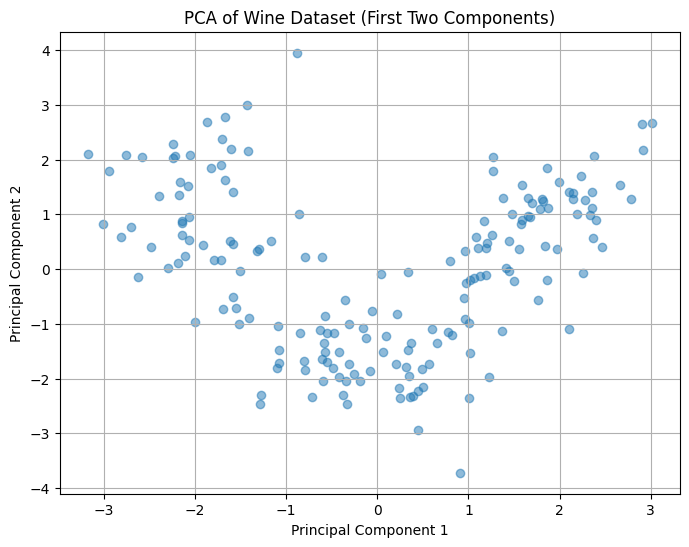

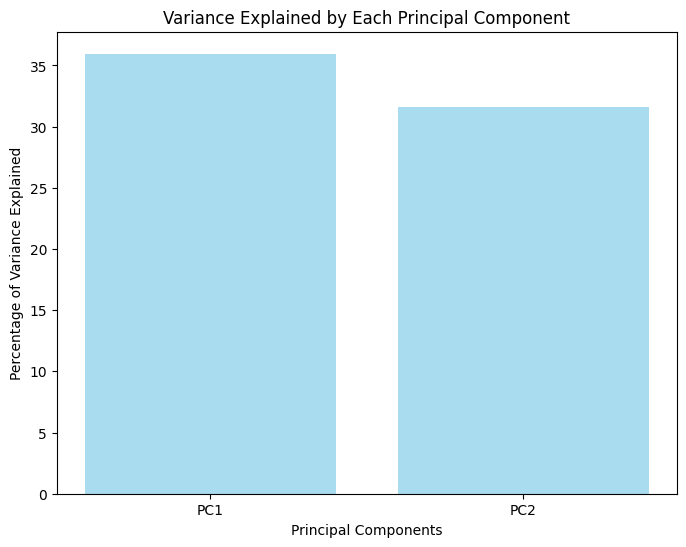

In [492]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset (replace with your actual file path or dataset loading code)
# Example: wine_data = pd.read_csv('wine.csv')
wine_data = fill.copy()

# Selecting only the columns of interest
columns_of_interest = ['Alcohol', 'Ash', 'Phenols', 'Color.int', 'Hue', 'OD', 'Proline']
wine_subset = wine_data[columns_of_interest]

# 1. Standardize the data
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine_subset)

# 2. Perform PCA
pca = PCA(n_components=2)
wine_pca = pca.fit_transform(wine_scaled)

# 3. Calculate percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_ * 100
print(f"Percentage of variance explained by PC1: {explained_variance[0]:.2f}%")
print(f"Percentage of variance explained by PC2: {explained_variance[1]:.2f}%")

# 4. Plot the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(wine_pca[:, 0], wine_pca[:, 1], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Dataset (First Two Components)')
plt.grid(True)
plt.show()

# 5. Plot explained variance ratio
plt.figure(figsize=(8, 6))
plt.bar(['PC1', 'PC2'], explained_variance, alpha=0.7, color='skyblue')
plt.ylabel('Percentage of Variance Explained')
plt.xlabel('Principal Components')
plt.title('Variance Explained by Each Principal Component')
plt.show()


**Analysis:**

The scatter plot of Principal Component 1 (PC1) against Principal Component 2 (PC2) demonstrates that these two components capture a significant amount of variance in the wine dataset, with PC1 accounting for 35.95% and PC2 for 31.61%, totaling 67.56%. The plot indicates a general positive correlation between PC1 and PC2, along with some signs of clustering, suggesting that these components successfully capture key patterns in the data. The substantial variance explained by these two components suggests they are effective for dimensionality reduction, retaining most of the dataset's variability while simplifying the original complexity.

**Further findings**

Percentage of variance explained by PC1: 35.95%
Percentage of variance explained by PC2: 31.61%
Percentage of variance explained by PC3: 12.48%
Percentage of variance explained by PC4: 7.86%
Percentage of variance explained by PC5: 5.05%
Percentage of variance explained by PC6: 4.29%
Percentage of variance explained by PC7: 2.77%


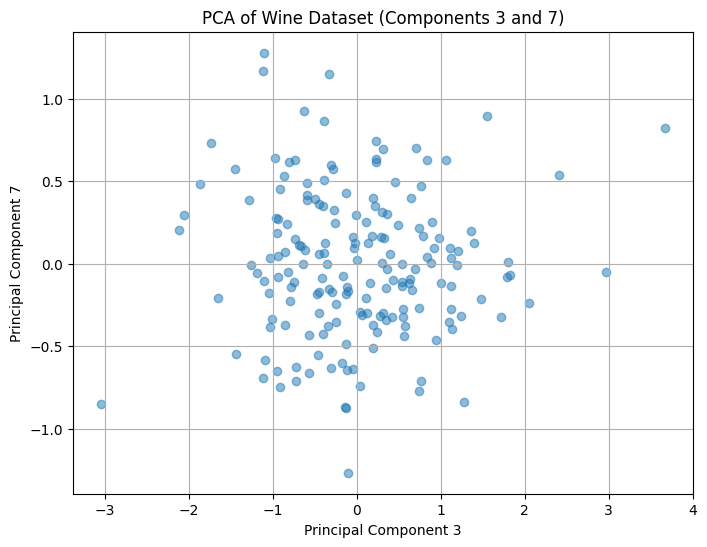

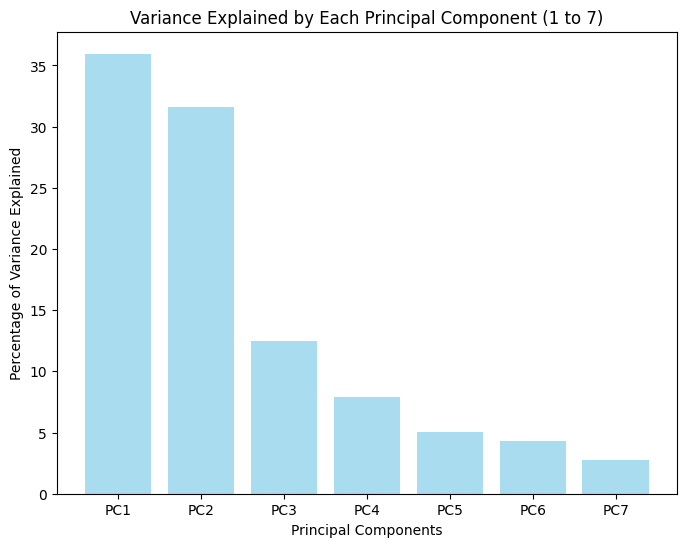

In [493]:
# 2. Perform PCA with 7 components
pca = PCA(n_components=7)
wine_pca = pca.fit_transform(wine_scaled)

# 3. Calculate percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_ * 100
for i, variance in enumerate(explained_variance, 1):
    print(f"Percentage of variance explained by PC{i}: {variance:.2f}%")

# 4. Plot the third and seventh principal components
plt.figure(figsize=(8, 6))
plt.scatter(wine_pca[:, 2], wine_pca[:, 6], alpha=0.5)
plt.xlabel('Principal Component 3')
plt.ylabel('Principal Component 7')
plt.title('PCA of Wine Dataset (Components 3 and 7)')
plt.grid(True)
plt.show()

# 5. Plot explained variance ratio for all 7 components
plt.figure(figsize=(8, 6))
plt.bar([f'PC{i}' for i in range(1, 8)], explained_variance, alpha=0.7, color='skyblue')
plt.ylabel('Percentage of Variance Explained')
plt.xlabel('Principal Components')
plt.title('Variance Explained by Each Principal Component (1 to 7)')
plt.show()

**Analysis:**

In contrast, the scatter plot of PC3 and PC7, which account for a much smaller portion of the variance, shows no clear clustering patterns, indicating that these components are less effective at capturing the underlying structure of the data.

**Limitation**

A major limitation of this PCA is that although the first two principal components (PC1 and PC2) account for the majority of the variance (67.56%), the subsequent components, especially PC3 and beyond, contribute significantly less. As a result, important information, such as non-linear relationships or subtle differences between data points, might be overlooked. Moreover, PCA assumes linearity, which makes it less suitable for datasets with complex, non-linear feature relationships.

**References**

Jana, D. K., Bhunia, P., Adhikary, S. D., & Mishra, A. (2023). Analyzing of salient features and classification of wine type based on quality through various neural network and support vector machine classifiers. Results in Control and Optimization, 11. https://www.sciencedirect.com/science/article/pii/S2666720723000218

The Wine Cellarage. (2023, February 17). A Guide to The Color of Wine (and what it can tell you). https://winecellarage.com/a-guide-to-the-color-of-wine-and-what-it-can-tell-you/